<a href="https://colab.research.google.com/github/Tashya924/ML-research-on-credit-risk-analysis/blob/modelresults02/ml_credit_report_intern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q lightgbm imbalanced-learn scikit-plot kagglehub[pandas-datasets]

In [4]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/default-of-credit-card-clients-dataset",
    "UCI_Credit_Card.csv"
)

target = "default.payment.next.month"
X = df.drop(columns=["ID", target])
y = df[target]

# --- 1. Original Methodology (Leaky) ---
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)
X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_res, y_res, test_size=0.25, random_state=42, shuffle=True
)
scaler_leaky = StandardScaler()
X_train_leaky_sc = scaler_leaky.fit_transform(X_train_leaky)
X_test_leaky_sc = scaler_leaky.transform(X_test_leaky)

# --- 2. Corrected Methodology (No Leakage) ---
X_train_raw, X_test_corr, y_train_raw, y_test_corr = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True
)
# Oversample ONLY the training set
X_train_corr, y_train_corr = ros.fit_resample(X_train_raw, y_train_raw)
scaler_corr = StandardScaler()
X_train_corr_sc = scaler_corr.fit_transform(X_train_corr)
X_test_corr_sc = scaler_corr.transform(X_test_corr)

print("Leaky Train Shape:", X_train_leaky.shape)
print("Corrected Train Shape:", X_train_corr.shape)

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Leaky Train Shape: (35046, 23)
Corrected Train Shape: (34982, 23)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Naive Bayes": GaussianNB(),
    "LGBM": LGBMClassifier(random_state=42, verbose=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "MLP": MLPClassifier(max_iter=500, random_state=42)
}

all_results = []

for scenario in ["Leaky", "Corrected"]:
    if scenario == "Leaky":
        xtr, xte, ytr, yte = X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky
        xtr_sc, xte_sc = X_train_leaky_sc, X_test_leaky_sc
    else:
        xtr, xte, ytr, yte = X_train_corr, X_test_corr, y_train_corr, y_test_corr
        xtr_sc, xte_sc = X_train_corr_sc, X_test_corr_sc

    for name, model in models_dict.items():
        use_sc = name in ["Logistic Regression", "KNN", "LDA", "MLP"]
        model.fit(xtr_sc if use_sc else xtr, ytr)
        preds = model.predict(xte_sc if use_sc else xte)
        probs = model.predict_proba(xte_sc if use_sc else xte)[:,1]

        all_results.append({
            "Algorithm": name, "Scenario": scenario,
            "Precision": precision_score(yte, preds), "Recall": recall_score(yte, preds),
            "F1": f1_score(yte, preds), "Accuracy": accuracy_score(yte, preds),
            "ROC_AUC": roc_auc_score(yte, probs)
        })

res_df = pd.DataFrame(all_results)
display(res_df.head())

,Algorithm,Scenario,Precision,Recall,F1,Accuracy,ROC_AUC
0,Logistic Regression,Leaky,0.681502,0.634658,0.657246,0.667779,0.718882
1,Decision Tree,Leaky,0.820289,0.959918,0.884627,0.874337,0.874119
2,KNN,Leaky,0.710817,0.823810,0.763154,0.743366,0.825009
3,Random Forest,Leaky,0.904389,0.966399,0.934367,0.931861,0.978697
4,Naive Bayes,Leaky,0.526905,0.938598,0.674925,0.546225,0.673258


In [5]:
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve

def threshold_plot(model,X,y,title):

    probs = model.predict_proba(X)[:,1]

    precision, recall, thresholds = precision_recall_curve(
        y,
        probs
    )

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-10)
    )

    queue_rate = [
        np.mean(probs >= t)
        for t in thresholds
    ]

    best_idx = np.argmax(f1)
    best_thresh = thresholds[best_idx]

    plt.figure(figsize=(10,6))

    plt.plot(thresholds,precision,label="Precision")
    plt.plot(thresholds,recall,label="Recall")
    plt.plot(thresholds,f1,label="F1 Score")
    plt.plot(thresholds,queue_rate,label="Queue Rate")

    plt.axvline(
        best_thresh,
        linestyle="--"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.show()

    print("Best Threshold:",round(best_thresh,4))
    print("Best F1:",round(f1[best_idx],4))

    return best_thresh

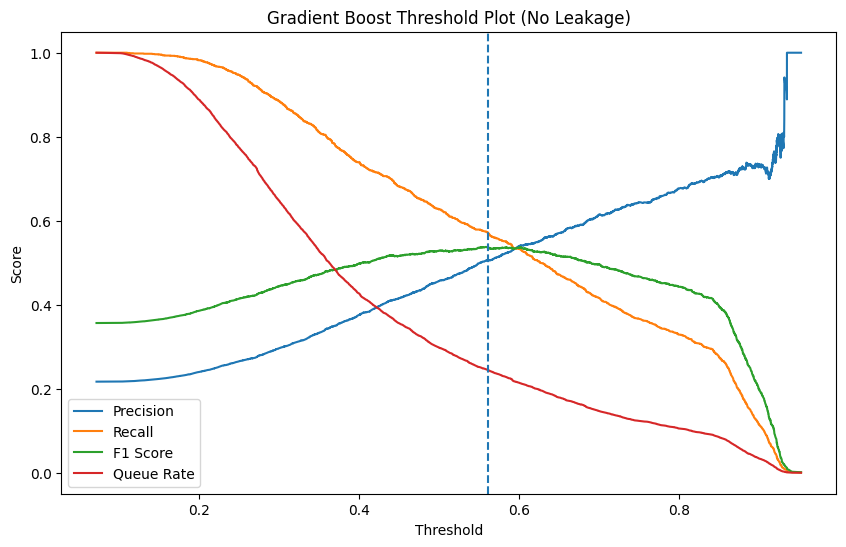

Best Threshold: 0.5603
Best F1: 0.5378


In [7]:
gb = models_dict["Gradient Boost"]

gb_thresh = threshold_plot(
    gb,
    X_test_corr_sc if "Gradient Boost" in ["Logistic Regression", "KNN", "LDA", "MLP"] else X_test_corr,
    y_test_corr,
    "Gradient Boost Threshold Plot (No Leakage)"
)

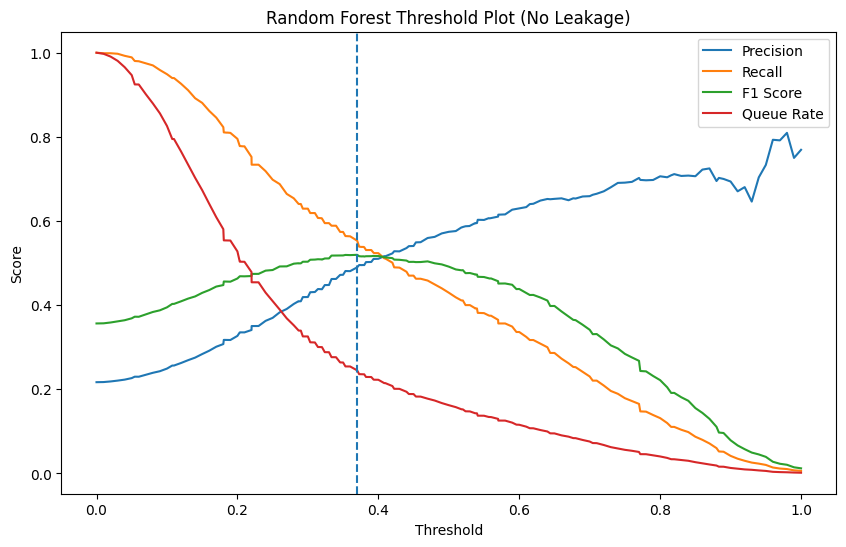

Best Threshold: 0.37
Best F1: 0.5196


In [8]:
rf = models_dict["Random Forest"]

rf_thresh = threshold_plot(
    rf,
    X_test_corr,
    y_test_corr,
    "Random Forest Threshold Plot (No Leakage)"
)

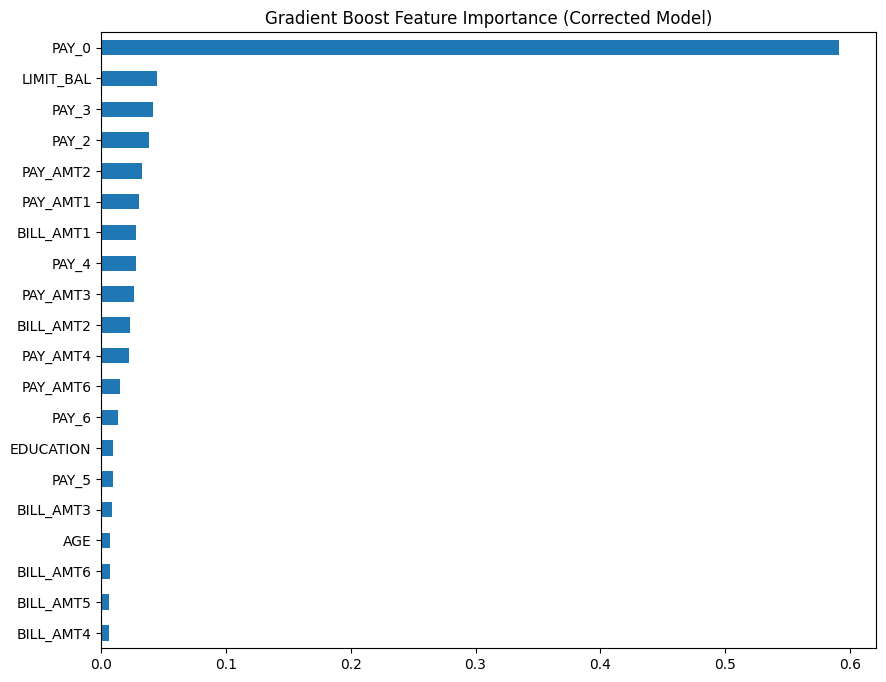

,0
PAY_0,0.591551
LIMIT_BAL,0.044554
PAY_3,0.041631
PAY_2,0.038606
PAY_AMT2,0.032291
PAY_AMT1,0.030528
BILL_AMT1,0.028049
PAY_4,0.027868
PAY_AMT3,0.026352
BILL_AMT2,0.023002


In [9]:
gb = models_dict["Gradient Boost"]
imp = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 8))
imp.tail(20).plot(kind="barh")
plt.title("Gradient Boost Feature Importance (Corrected Model)")
plt.show()

display(imp.sort_values(ascending=False).head(20))

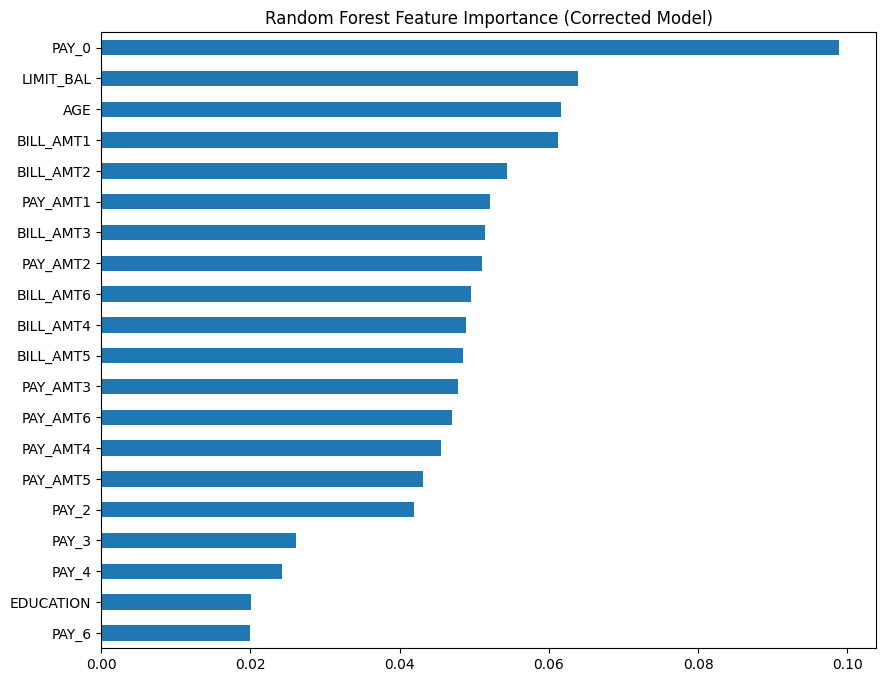

,0
PAY_0,0.098905
LIMIT_BAL,0.063904
AGE,0.061673
BILL_AMT1,0.061203
BILL_AMT2,0.054369
PAY_AMT1,0.052070
BILL_AMT3,0.051476
PAY_AMT2,0.051026
BILL_AMT6,0.049607
BILL_AMT4,0.048847


In [10]:
rf = models_dict["Random Forest"]
imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 8))
imp.tail(20).plot(kind="barh")
plt.title("Random Forest Feature Importance (Corrected Model)")
plt.show()

display(imp.sort_values(ascending=False).head(20))

In [11]:
# Using X_train_corr and y_train_corr to ensure hyperparameter tuning is leakage-free
from sklearn.model_selection import GridSearchCV

rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

gb_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_search.fit(X_train_corr, y_train_corr)
gb_search.fit(X_train_corr, y_train_corr)

print("Best RF Params:", rf_search.best_params_)
print("Best GB Params:", gb_search.best_params_)

Best RF Params: {'max_depth': None, 'n_estimators': 200}
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [12]:
print("Corrected Train Class Distribution (Oversampled):")
print(y_train_corr.value_counts(normalize=True))
print("\nCorrected Test Class Distribution (Original):")
print(y_test_corr.value_counts(normalize=True))

Corrected Train Class Distribution (Oversampled):
default.payment.next.month
0    0.5
1    0.5
Name: proportion, dtype: float64

Corrected Test Class Distribution (Original):
default.payment.next.month
0    0.783067
1    0.216933
Name: proportion, dtype: float64


In [13]:
comparison = res_df.pivot(index='Algorithm', columns='Scenario')
comparison.columns = [f'{col[0]}_{col[1]}' for col in comparison.columns]

# Calculate F1 Difference as primary metric for analysis
comparison['F1_Diff_Abs'] = comparison['F1_Leaky'] - comparison['F1_Corrected']
comparison['F1_Diff_Pct'] = (comparison['F1_Diff_Abs'] / comparison['F1_Corrected']) * 100

styled_comp = comparison.sort_values("F1_Diff_Abs", ascending=False).style.background_gradient(subset=['F1_Diff_Abs'], cmap='Reds')
display(styled_comp)

print("\n--- Analysis ---")
print(f"Average F1 inflation due to leakage: {comparison['F1_Diff_Abs'].mean():.4f}")
max_impact = comparison['F1_Diff_Abs'].idxmax()
print(f"Most affected model: {max_impact} (Inflation: {comparison.loc[max_impact, 'F1_Diff_Abs']:.4f})")

,Precision_Corrected,Precision_Leaky,Recall_Corrected,Recall_Leaky,F1_Corrected,F1_Leaky,Accuracy_Corrected,Accuracy_Leaky,ROC_AUC_Corrected,ROC_AUC_Leaky,F1_Diff_Abs,F1_Diff_Pct
Algorithm,,,,,,,,,,,,
Decision Tree,0.393313,0.820289,0.397664,0.959918,0.395477,0.884627,0.736267,0.874337,0.613935,0.874119,0.489151,123.686329
Random Forest,0.576142,0.904389,0.418562,0.966399,0.484870,0.934367,0.807067,0.931861,0.759597,0.978697,0.449497,92.704568
KNN,0.346426,0.710817,0.601721,0.823810,0.439704,0.763154,0.667333,0.743366,0.683197,0.825009,0.323450,73.560960
Naive Bayes,0.234046,0.526905,0.921942,0.938598,0.373320,0.674925,0.328533,0.546225,0.668617,0.673258,0.301605,80.789878
MLP,0.420584,0.726066,0.610326,0.746376,0.497994,0.736081,0.733067,0.731382,0.750661,0.810745,0.238087,47.809164
LGBM,0.455292,0.780067,0.613399,0.710217,0.522650,0.743505,0.756933,0.754066,0.774413,0.843023,0.220855,42.256802
Logistic Regression,0.376394,0.681502,0.642901,0.634658,0.474807,0.657246,0.691467,0.667779,0.724733,0.718882,0.182439,38.423865
LDA,0.384673,0.689414,0.629379,0.622037,0.477501,0.653994,0.701200,0.669663,0.721851,0.717324,0.176494,36.962019
Gradient Boost,0.457399,0.766491,0.626921,0.646086,0.528908,0.701157,0.757733,0.723592,0.779994,0.796731,0.172248,32.566767



--- Analysis ---
Average F1 inflation due to leakage: 0.2691
Most affected model: Decision Tree (Inflation: 0.4892)


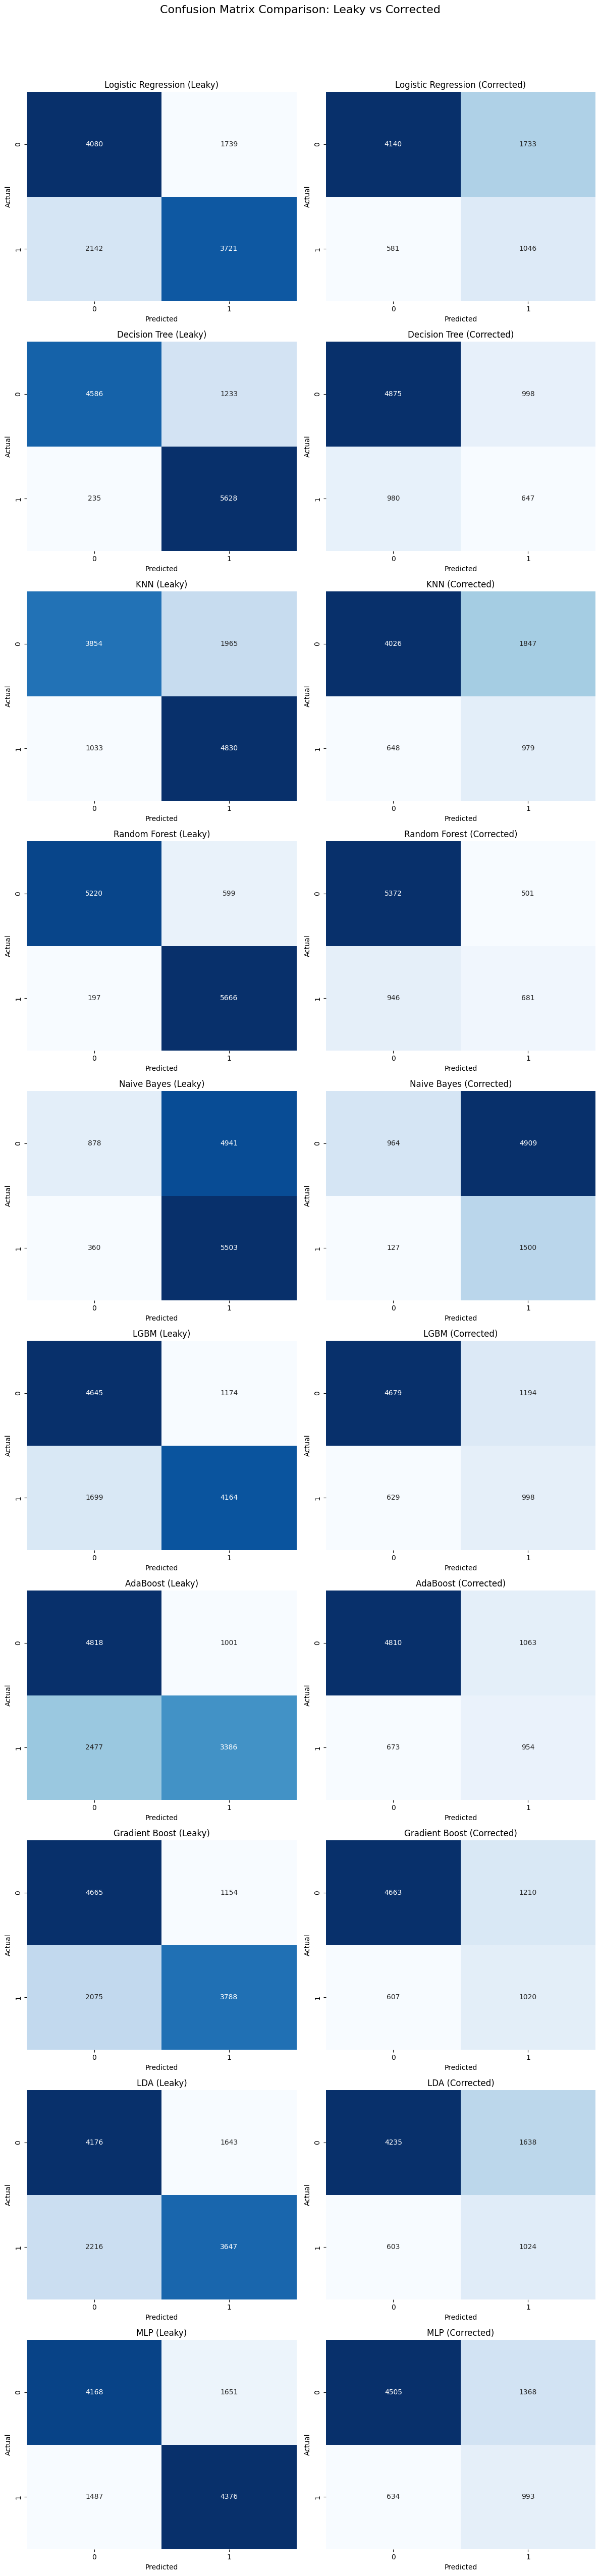

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(res_df, models_dict):
    algorithms = res_df['Algorithm'].unique()
    n_alg = len(algorithms)

    fig, axes = plt.subplots(n_alg, 2, figsize=(12, 5 * n_alg))
    fig.suptitle('Confusion Matrix Comparison: Leaky vs Corrected', fontsize=16, y=1.02)

    for i, alg in enumerate(algorithms):
        for j, scenario in enumerate(['Leaky', 'Corrected']):
            ax = axes[i, j]

            # Setup data based on scenario
            if scenario == 'Leaky':
                xte, yte = (X_test_leaky_sc, y_test_leaky) if alg in ['Logistic Regression', 'KNN', 'LDA', 'MLP'] else (X_test_leaky, y_test_leaky)
            else:
                xte, yte = (X_test_corr_sc, y_test_corr) if alg in ['Logistic Regression', 'KNN', 'LDA', 'MLP'] else (X_test_corr, y_test_corr)

            # We need to re-fit or use the stored models. Since we didn't store individual scenario models,
            # we quickly re-fit for this visualization to ensure accuracy.
            model = models_dict[alg]
            if scenario == 'Leaky':
                xtr, ytr = (X_train_leaky_sc, y_train_leaky) if alg in ['Logistic Regression', 'KNN', 'LDA', 'MLP'] else (X_train_leaky, y_train_leaky)
            else:
                xtr, ytr = (X_train_corr_sc, y_train_corr) if alg in ['Logistic Regression', 'KNN', 'LDA', 'MLP'] else (X_train_corr, y_train_corr)

            model.fit(xtr, ytr)
            y_pred = model.predict(xte)
            cm = confusion_matrix(yte, y_pred)

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
            ax.set_title(f'{alg} ({scenario})')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(res_df, models_dict)